# ESP32 CO2 sensor data analysis

## Data cleanup

In this notebook, we will clean up the data collected from the ESP32 CO2 sensor. The goal is to remove any outliers, handle missing values, and prepare the dataset for further analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pathlib
from pathlib import Path


### Loading the data from CSV

In [18]:
# the file is in ../../data_analysis/sensor-readings.csv construct the path to the CSV file using pathlib
# __file__ isn't defined in notebooks, so resolve relative to the current working directory instead
current_dir = Path.cwd()
data_file_path = current_dir.parent.parent / 'data_analysis' / 'sensor-readings-full.csv'

# Load the data from the CSV file with pandas, specifying the correct encoding
data = pd.read_csv(data_file_path, encoding='utf-8')


In [19]:
data.describe()


,id,esp_index,unix_time,temperature_c,humidity_pct,aqi,tvoc_ppb,eco2_ppm,ens_validity,has_aht,has_ens,ingested_at
count,208703.000000,208703.000000,2.087030e+05,205429.000000,205429.000000,206409.000000,206409.000000,206409.000000,208703.000000,208703.000000,208703.000000,2.087030e+05
mean,234298.622727,41.973556,1.776505e+09,29.204650,49.390492,3.422142,1685.924315,1125.513151,0.010053,0.984313,0.989008,1.779601e+09
std,130637.085831,69.605680,6.407984e+07,2.031676,9.769371,1.154940,2981.235184,1197.727651,0.139251,0.124263,0.104264,3.294209e+06
min,1.000000,1.000000,2.200000e+01,16.690000,19.820000,1.000000,0.000000,400.000000,0.000000,0.000000,0.000000,1.776352e+09
25%,92736.500000,1.000000,1.775168e+09,27.860000,42.370000,3.000000,223.000000,721.000000,0.000000,1.000000,1.000000,1.776354e+09
50%,287882.000000,1.000000,1.778428e+09,29.140000,50.560000,3.000000,600.000000,896.000000,0.000000,1.000000,1.000000,1.778428e+09
75%,340057.500000,65.000000,1.782678e+09,30.430000,56.770000,4.000000,1901.000000,1198.000000,0.000000,1.000000,1.000000,1.782678e+09
max,392233.000000,240.000000,1.785858e+09,36.870000,99.990000,5.000000,65000.000000,44873.000000,2.000000,1.000000,1.000000,1.785858e+09


In [20]:
data.head()


,id,device_url,source,esp_index,unix_time,temperature_c,humidity_pct,aqi,tvoc_ppb,eco2_ppm,ens_validity,has_aht,has_ens,ingested_at
0,1,http://192.168.10.27,sd,1,22,32.14,40.38,1.0,24.0,400.0,0,1,1,1776352114
1,2,http://192.168.10.27,sd,2,24,32.17,40.34,NaN,NaN,NaN,2,1,0,1776352114
2,3,http://192.168.10.27,sd,3,25,32.17,40.29,NaN,NaN,NaN,2,1,0,1776352114
3,4,http://192.168.10.27,sd,4,26,32.29,40.32,NaN,NaN,NaN,2,1,0,1776352114
4,5,http://192.168.10.27,sd,5,27,32.17,40.17,NaN,NaN,NaN,2,1,0,1776352114


In [21]:
data.tail()


,id,device_url,source,esp_index,unix_time,temperature_c,humidity_pct,aqi,tvoc_ppb,eco2_ppm,ens_validity,has_aht,has_ens,ingested_at
208698,392229,http://192.168.10.27,nvs,1,1785857378,28.23,54.69,2.0,207.0,702.0,0,1,1,1785857466
208699,392230,http://192.168.10.27,nvs,1,1785857439,28.03,55.25,3.0,221.0,719.0,0,1,1,1785857526
208700,392231,http://192.168.10.27,nvs,1,1785857500,27.98,55.64,2.0,203.0,697.0,0,1,1,1785857587
208701,392232,http://192.168.10.27,nvs,1,1785857561,27.94,55.45,2.0,193.0,685.0,0,1,1,1785857647
208702,392233,http://192.168.10.27,nvs,1,1785857622,28.01,55.57,2.0,202.0,696.0,0,1,1,1785857707


In [22]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 208703 entries, 0 to 208702
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             208703 non-null  int64  
 1   device_url     208703 non-null  str    
 2   source         208703 non-null  str    
 3   esp_index      208703 non-null  int64  
 4   unix_time      208703 non-null  int64  
 5   temperature_c  205429 non-null  float64
 6   humidity_pct   205429 non-null  float64
 7   aqi            206409 non-null  float64
 8   tvoc_ppb       206409 non-null  float64
 9   eco2_ppm       206409 non-null  float64
 10  ens_validity   208703 non-null  int64  
 11  has_aht        208703 non-null  int64  
 12  has_ens        208703 non-null  int64  
 13  ingested_at    208703 non-null  int64  
dtypes: float64(5), int64(7), str(2)
memory usage: 22.3 MB


The data is a csv file representing the contents of the database table. Some columns represent no interesting data, so we will leave only following columns:
- `unix_time`: The timestamp of the reading in Unix time format.
- `temperature_c`: The temperature reading in Celsius.
- `humidity_pct`: The humidity reading in percentage.
- `aqi`: The air quality index reading.
- `tvoc_ppb`: The total volatile organic compounds reading in parts per billion.
- `eco2_ppm`: The equivalent CO2 reading in parts per million.
- `ens_validity`: The validity of the environmental sensor reading.

In [23]:
# Filter the DataFrame to keep only the relevant columns
columns_to_keep = ['unix_time', 'temperature_c', 'humidity_pct', 'aqi', 'tvoc_ppb', 'eco2_ppm', 'ens_validity']

filtered_data = data[columns_to_keep]

filtered_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 208703 entries, 0 to 208702
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   unix_time      208703 non-null  int64  
 1   temperature_c  205429 non-null  float64
 2   humidity_pct   205429 non-null  float64
 3   aqi            206409 non-null  float64
 4   tvoc_ppb       206409 non-null  float64
 5   eco2_ppm       206409 non-null  float64
 6   ens_validity   208703 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 11.1 MB


At this point we can already see that the amount of not-null values for each column is different. For the analysis simplicity, we will remove any rows that have missing values in any of the columns.

In [ ]:
# Remove rows with any missing values
cleaned_data = filtered_data.dropna()

cleaned_data.info()


<class 'pandas.DataFrame'>
Index: 204321 entries, 0 to 208702
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   unix_time      204321 non-null  int64  
 1   temperature_c  204321 non-null  float64
 2   humidity_pct   204321 non-null  float64
 3   aqi            204321 non-null  float64
 4   tvoc_ppb       204321 non-null  float64
 5   eco2_ppm       204321 non-null  float64
 6   ens_validity   204321 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 12.5 MB


Okay, only non-null rows are left, however, this still does not mean that we have only valid readings. Due to the problems with EPS32 internal time settings, some readings were recorded with a timestamp close to 0, which is not a valid timestamp. To visually represent these values, let's plot the temperature over time (same incorrect readings were made for humidity, AQI, TVOC, and eCO2). The plot will help us identify any outliers or anomalies in the data.

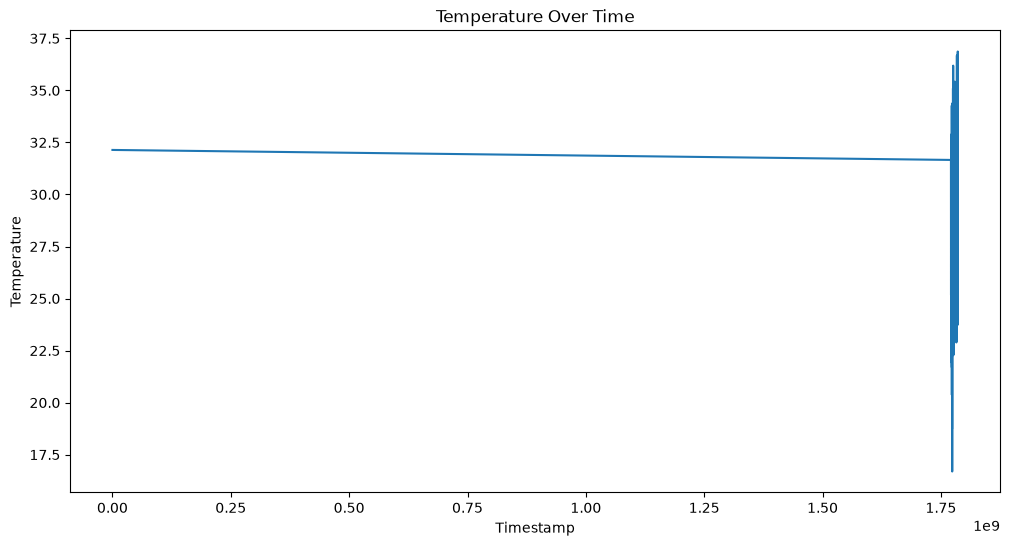

In [ ]:
# plot the temperature over time to identify any outliers or anomalies in the data
plt.figure(figsize=(12, 6))

plt.plot(cleaned_data['unix_time'], cleaned_data['temperature_c'])
plt.xlabel('Timestamp')
plt.ylabel('Temperature')
plt.title('Temperature Over Time')
plt.show()


Just as we expected, we can see that there are some readings with a timestamp close to 0. This project was started in 2026, so any readings with a timestamp before that are invalid. We will remove any rows with a timestamp less than 2026-01-01 00:00:00 (Unix time 1767225600).

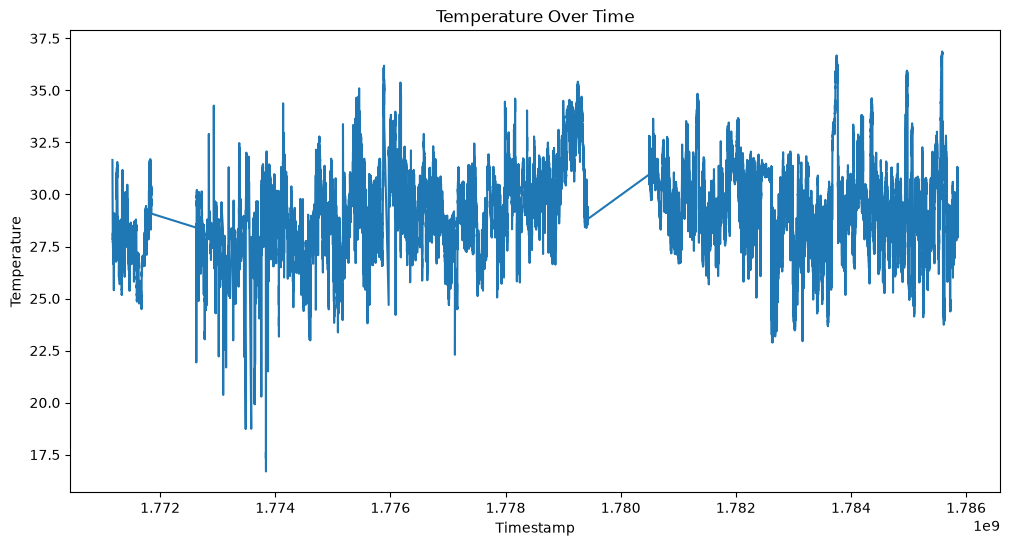

In [28]:
# Remove rows with any timestamp less than 2026-01-01 00:00:00 (Unix time 1767225600)
valid_timestamp = 1767225600

cleaned_data = cleaned_data[cleaned_data['unix_time'] >= valid_timestamp]

# now let's plot the temperature over time again to see if the outliers have been removed
plt.figure(figsize=(12, 6))
plt.plot(cleaned_data['unix_time'], cleaned_data['temperature_c'])
plt.xlabel('Timestamp')
plt.ylabel('Temperature')
plt.title('Temperature Over Time')
plt.show()


Okay, this looks much better. We can still see some measurement periods missing, but this not related to the data cleanup, but rather to the sensor itself. Due to the sensor malfunction or service, there were some periods of time when the sensor was not able to provide readings. 

With that being said, let's save the cleaned data to a new CSV file for further analysis.

In [ ]:
# Save the cleaned data to a new CSV file for further analysis
cleaned_data_file_path = current_dir.parent.parent / 'data_analysis' / 'sensor-readings-cleaned.csv'
cleaned_data.to_csv(cleaned_data_file_path, index=False, encoding='utf-8')


In [ ]:
# Load the cleaned data from the new CSV file to verify that it was saved correctly
loaded_cleaned_data = pd.read_csv(cleaned_data_file_path, encoding='utf-8')
# Use pandas to display the first few rows of the loaded cleaned data
loaded_cleaned_data.head()


,unix_time,temperature_c,humidity_pct,aqi,tvoc_ppb,eco2_ppm,ens_validity
0,1771171985,31.66,41.36,1.0,24.0,400.0,0
1,1771172729,31.12,40.64,1.0,24.0,400.0,0
2,1771176516,28.02,44.72,2.0,84.0,523.0,0
3,1771176576,27.97,44.50,1.0,59.0,474.0,0
4,1771176637,27.95,44.47,2.0,69.0,494.0,0
